<a href="https://colab.research.google.com/github/ryueuitae-blip/AIEYES-STUDY/blob/huisoo_branch/chapter3_titanic_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
#분석환경 세팅

#시각화 결과를 별도의 창이 아닌 결과 셀에 표시
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt #시각화 라이브러리
import seaborn as sns #matplotlib 기반의 시각화 라이브러리, 편의성 향

import warnings
warnings.filterwarnings('ignore') #코드 실행 시 불필요한 경고창 없애기


# **Titanic 데이터셋의 기본 정보**
### 데이터 피처

- Pclass: 승객 등급 (1등석,2등석,3등석)
- Survived: 생존 여부 (0 = 사망, 1 = 생존)
- Name: 이름
- Sex: 성별
- Age: 나이(세)
- Sibsp: 탑승한 형제/배우자 수
- Parch: 탑승한 부모/자녀 수
- Ticket: 티켓 번호
- Fare: 승객 운임(요금)
- Cabin: 선실 이름
- Embarked: 탑승 항구(C = 쉘 부르그, Q = 퀸즈타운, S = 사우스 햄튼)

##### 아래는 사용 데이터셋에 없는 피처
- body: 사망자 확인 번호
- home dest: 고향/목적지

In [43]:
#훈련 데이터와 테스트 데이터를 불러옴
df_train = pd.read_csv('/content/train.csv')
df_test = pd.read_csv('/content/test.csv')

#처음으로부터 5개의 데이터를 조회해보기...
df_train.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
#info()함수를 통해 데이터의 정보를 확인(칼럼명, NULL아닌 값 카운트, 자료형 등)
print(df_train.info())
print('-------------------------')
print(df_test.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
-------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 no

In [44]:
#불필요한 피처 제거(성별을 제외한 텍스트 피처 제거)
df_train = df_train.drop(['Name','Ticket','Cabin'],axis=1)
df_test = df_test.drop(['Name','Ticket','Cabin'],axis=1)

Survived
0    549
1    342
Name: count, dtype: int64


<Axes: xlabel='Survived'>

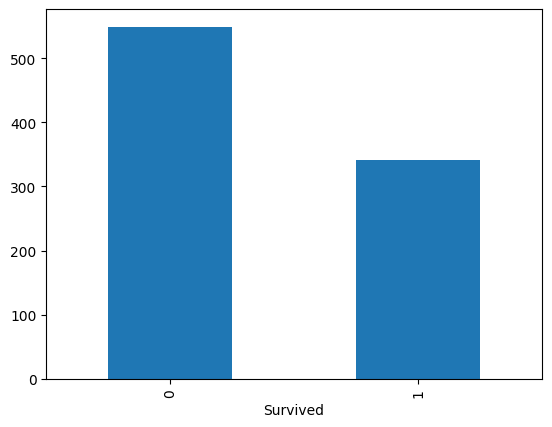

In [ ]:
#탐색적 데이터 분석

#value_count(): 각 value가 얼마나 많은지 카운트
print(df_train['Survived'].value_counts())

#plot.bar()를 통해 막대그래프 형태로 그래프 출력
df_train['Survived'].value_counts().plot.bar()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64


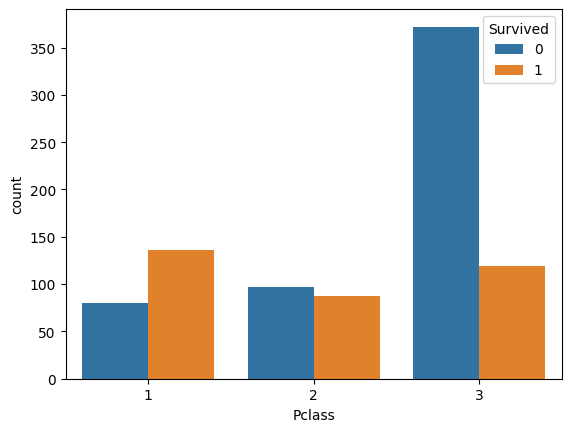

In [ ]:
#Survived 피쳐를 기준으로 그룹을 나눈 후 그룹별 pclass 피쳐의 분포 확인

#Pclass에 따른 개수 확인
print(df_train['Pclass'].value_counts())

ax = sns.countplot(x='Pclass', hue='Survived', data=df_train)

#승객 등급이 낮을수록 생존 인원보다 사망 인원이 비교적 많은 씁쓸한 결과를 볼 수 있음

In [ ]:
from scipy import stats

#두 집단의 피처를 비교하며 탐색작업을 자동화하는 함수 정의
def valid_features(df, col_name, distribution_check=True):

    #두 집단(Survived=1, Survived=0)의 분포 그래프를 출력
    g = sns.FacetGrid(df, col='Survived')
    g.map(plt.hist, col_name, bins = 30)

    #두 집단(Survived=1, Survived=0)의 표준편차를 각각 출력
    titanic_survived = df[df['Survived']==1]
    titanic_survived_static = np.array(titanic_survived[col_name])
    print("data std is", "%.2f" %np.std(titanic_survived_static))
    titanic_not_survived = df[df['Survived']==0]
    titanic_not_survived_static = np.array(titanic_not_survived[col_name])
    print("data std is", "%.2f" %np.std(titanic_not_survived_static))

    #T-test로 두 집단의 평균 차이 검정(ttest 함수 사용)
    tTestResult = stats.ttest_ind(titanic_survived[col_name], titanic_not_survived[col_name])
    tTestResultDiffVar = stats.ttest_ind(titanic_survived[col_name], titanic_not_survived[col_name], equal_var=False)
    print("The t-statistic and p-value assuming equal variances is %.3f and %.3f."%tTestResult)
    print("The t-statistic and p-value not assuming equal variances is %.3f and %.3f."%tTestResultDiffVar)

    if distribution_check:
        #Shapiro-Wilk 검정: 분포의 정규성 정도 검증
        print("The w-statistic and p-value for Survived is %.3f and %.3f."%stats.shapiro(titanic_survived[col_name]))
        print("The w-statistic and p-value for Not Survived is %.3f and %.3f."%stats.shapiro(titanic_not_survived[col_name]))

### Shapiro-Wilk 검정

주어진 데이터가 얼마나 정규성(정규분포)을 따르는지를 측정하는 검정 방법
대부분의 통계/데이터 분석은 데이터가 정규성을 띈다고 가정함 (T-test도 그러하다)

p-value > 0.05 => 정규분포를 따른다

p-value < 0.05 => 정규분포를 따르지 않는다

주의> 샘플 수가 너무 많으면(보통 5,000개 이상) 아주 작은 차이에도 p-value가 낮게 나오기도 함



### T-test

주어진 집단의 평균이 통계적으로 유의미하게 다른지 보는 테스트.

다음을 전제로 한다. 1. 정규성, 2. 등분산성


p-value < 0.05 => 두 집단의 평균은 차이가 있다.

p-value > 0.05 => 두 집단의 평균은 차이가 없다.

data std is 14.93
data std is 14.16
The t-statistic and p-value assuming equal variances is -2.067 and 0.039.
The t-statistic and p-value not assuming equal variances is -2.046 and 0.041.
The w-statistic and p-value for Survived is 0.983 and 0.001.
The w-statistic and p-value for Not Survived is 0.969 and 0.000.


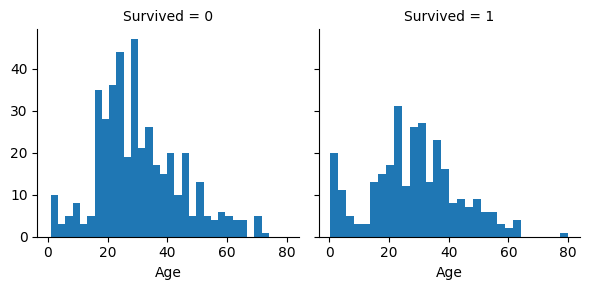

In [ ]:
#나이가 0보다 클때, 생존자와 사망자 간 나이 분포 / T-test 결과 / 검정결과 반환
valid_features(df_train[df_train['Age'] > 0], "Age", distribution_check=True)

data std is 0.71
data std is 1.29
The t-statistic and p-value assuming equal variances is -1.054 and 0.292.
The t-statistic and p-value not assuming equal variances is -1.194 and 0.233.


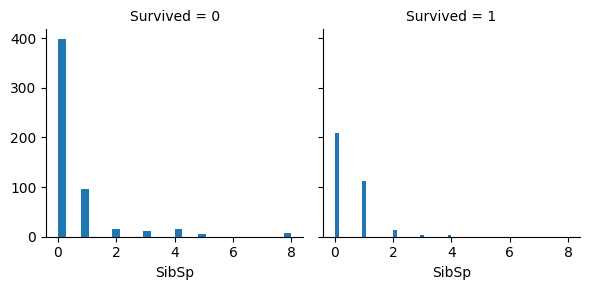

In [ ]:
#SibSp 피쳐 탐색
valid_features(df_train, "SibSp", distribution_check=False)

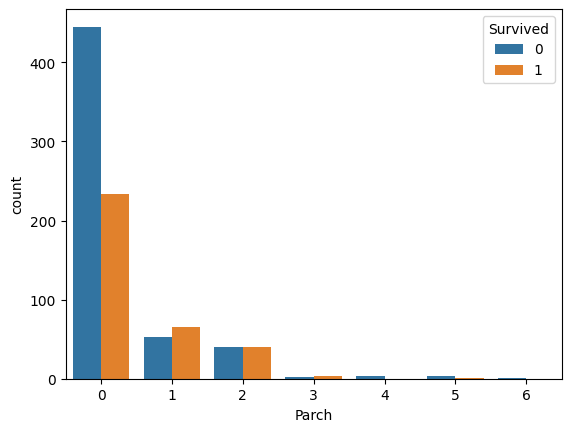

In [ ]:
ax = sns.countplot(x='Parch', hue='Survived', data=df_train)

#탑승한 부모 자녀가 많을수록 사망 인원이 생존 인원보다 비교적 많음

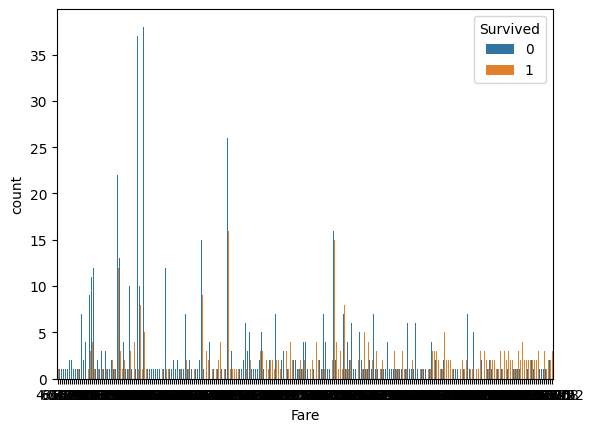

In [ ]:
ax = sns.countplot(x='Fare', hue='Survived', data=df_train)

#높은 요금을 낸 승객이 그렇지 않은 승객보다 생존 비율이 더 높음

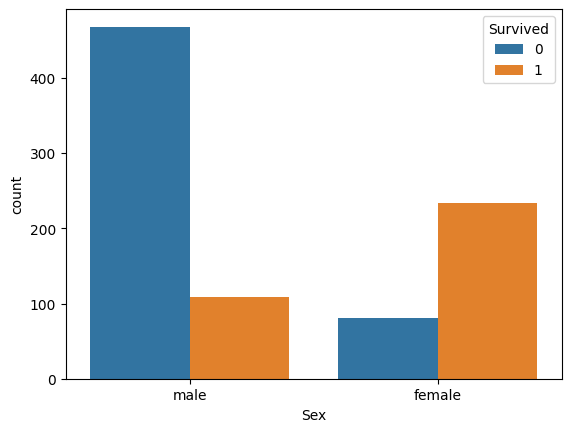

In [ ]:
ax = sns.countplot(x='Sex', hue='Survived', data=df_train)

#남성은 사망 인원이 생존 인원보다 많고, 여성은 생존 인원이 사망 인원보다 많음

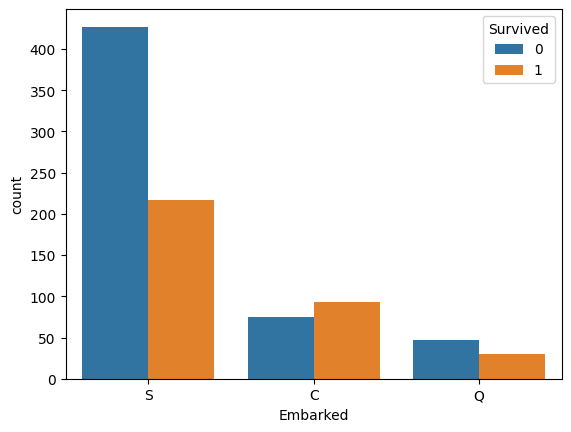

In [ ]:
ax = sns.countplot(x='Embarked', hue='Survived', data=df_train)

#사우스 햄튼에서 승선한 인원이 대다수이며, 쉘 부르그의 승객들만 생존 인원이 사망 인원보다 많은 특징을 보임

### 생존자 분류 모델 만들기

In [45]:
from numpy._core.defchararray import replace
#결측치 처리

#Age: 결측값을 평균값으로 대체
replace_mean = df_train[df_train['Age'] > 0]['Age'].mean()
df_train['Age'] = df_train['Age'].fillna(replace_mean) #fillna() 결측치를 괄호 안 값으로 대체하는 메서드
df_test['Age'] = df_test['Age'].fillna(replace_mean)

#Embarked: 결측값을 최빈값으로 대체
embarked_mode = df_train['Embarked'].value_counts().index[0]
df_train['Embarked'] = df_train['Embarked'].fillna(embarked_mode)
df_test['Embarked'] = df_test['Embarked'].fillna(embarked_mode)

#원-핫 인코딩을 위한 통합 데이터 프레임(whole_df) 생성
whole_df = pd.concat([df_train, df_test]) #강의 영상에서는 append를 사옹했으나 pandas 2.0부터는 append() 삭제, 대신 concat 이용
train_idx_num = len(df_train)

#pandas 패키지를 이용해 원-핫 인코딩 수행
whole_df_encoded = pd.get_dummies(whole_df)
df_train = whole_df_encoded[:train_idx_num]
df_test = whole_df_encoded[train_idx_num:]

df_train.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,1,0.0,3,22.0,1,0,7.2500,False,True,False,False,True
1,2,1.0,1,38.0,1,0,71.2833,True,False,True,False,False
2,3,1.0,3,26.0,0,0,7.9250,True,False,False,False,True
3,4,1.0,1,35.0,1,0,53.1000,True,False,False,False,True
4,5,0.0,3,35.0,0,0,8.0500,False,True,False,False,True


In [46]:
#데이터를 학습 데이터셋, 테스트 데이터셋으로 분리

x_train, y_train = df_train.loc[:,df_train.columns != 'Survived'].values, df_train['Survived'].values
x_test, y_test = df_test.loc[:,df_test.columns != 'Survived'].values, df_test['Survived'].values